## Modelo de Clasificación — Random Forest
### Predicción de Default en Préstamos

### 1. Importar Librerías

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score
)

from xgboost import XGBClassifier

%matplotlib inline
sns.set(style='whitegrid')

### 2. Cargar el Dataset Limpio

In [9]:
df = pd.read_csv('Loan_default_limpio.csv')
print('Dimensiones:', df.shape)
df.head()

Dimensiones: (255347, 25)


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,1,...,False,False,False,False,False,False,False,False,False,True
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,False,False,False,False,True,False,False,False,False,True
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,False,False,False,True,False,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,False,False,False,False,True,False,True,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,False,False,False,True,False,False,False,False,False,False


### 2. Separar Variables Predictoras (X) y Variable Objetivo (y)

In [4]:
# Selección de características: se reducen las 24 variables originales a las 6 más relevantes
FEATURES = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines']

X = df[FEATURES]
y = df['Default']

print('Variables seleccionadas:', FEATURES)
print('Variables predictoras (X):', X.shape)
print('Variable objetivo (y):', y.shape)

Variables seleccionadas: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines']
Variables predictoras (X): (255347, 6)
Variable objetivo (y): (255347,)


In [10]:
print('Balance de clases (%):')
print(np.round(y.value_counts(normalize=True) * 100, 2))

Balance de clases (%):
Default
0    88.39
1    11.61
Name: proportion, dtype: float64


### 3. Dividir en Conjunto de Entrenamiento y Prueba

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Tamaño entrenamiento:', X_train.shape)
print('Tamaño prueba:', X_test.shape)

Tamaño entrenamiento: (204277, 6)
Tamaño prueba: (51070, 6)


### 3.1 Selección de Características

Se aplicó selección manual basada en criterio de dominio y relevancia estadística, reduciendo las 24 variables originales a **6 características clave**: `Age`, `Income`, `LoanAmount`, `CreditScore`, `MonthsEmployed`, `NumCreditLines`. Estas variables representan el perfil financiero y laboral del solicitante, que son los factores más predictivos del riesgo de default.

### 4. Entrenar el Modelo Base — Random Forest

In [12]:
rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_base.fit(X_train, y_train)
print('Modelo base entrenado exitosamente')

Modelo base entrenado exitosamente


### 5. Predicciones del Modelo Base

In [13]:
y_pred_rf_base = rf_base.predict(X_test)
y_prob_rf_base = rf_base.predict_proba(X_test)[:, 1]

print('Primeras 10 predicciones:', y_pred_rf_base[:10])
print('Primeras 10 probabilidades:', np.round(y_prob_rf_base[:10], 2))

Primeras 10 predicciones: [0 0 0 0 0 0 0 0 0 0]
Primeras 10 probabilidades: [0.1  0.07 0.04 0.08 0.12 0.04 0.36 0.02 0.29 0.06]


### 6. Evaluación del Modelo Base

In [14]:
accuracy_rf_base = accuracy_score(y_test, y_pred_rf_base)
precision_rf_base = precision_score(y_test, y_pred_rf_base, zero_division=0)
recall_rf_base = recall_score(y_test, y_pred_rf_base, zero_division=0)
f1_rf_base = f1_score(y_test, y_pred_rf_base, zero_division=0)

print(f'Accuracy:  {accuracy_rf_base:.4f}')
print(f'Precision: {precision_rf_base:.4f}')
print(f'Recall:    {recall_rf_base:.4f}')
print(f'F1-score:  {f1_rf_base:.4f}')

Accuracy:  0.8846
Precision: 0.5512
Recall:    0.0336
F1-score:  0.0633


In [15]:
print('Reporte de Clasificación:')
print(classification_report(y_test, y_pred_rf_base, target_names=['No Default', 'Default']))

Reporte de Clasificación:
              precision    recall  f1-score   support

  No Default       0.89      1.00      0.94     45139
     Default       0.55      0.03      0.06      5931

    accuracy                           0.88     51070
   macro avg       0.72      0.51      0.50     51070
weighted avg       0.85      0.88      0.84     51070



### 7. Optimización de Random Forest con GridSearchCV

In [16]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print('Mejores parámetros Random Forest:')
print(grid_rf.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Mejores parámetros Random Forest:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}


### 8. Entrenamiento de XGBoost con GridSearchCV

In [17]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print('Mejores parámetros XGBoost:')
print(grid_xgb.best_params_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Mejores parámetros XGBoost:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}


### 8.1 Entrenamiento de Regresión Logística con RandomizedSearchCV

Para mejorar la eficiencia computacional, el escalado de variables se realiza **una sola vez** y se reutiliza tanto en Regresión Logística como en SVM.  
Esto evita recalcular transformaciones innecesarias y mantiene consistencia entre modelos lineales.

La Regresión Logística funciona como un **baseline interpretable**, con bajo costo computacional y buen desempeño en problemas de clasificación binaria.

In [18]:
# Escalado de variables (solo una vez; se reutiliza para Regresión Logística y SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Regresión Logística optimizada con RandomizedSearchCV
param_dist_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [300]
}

grid_lr = RandomizedSearchCV(
    estimator=LogisticRegression(
        class_weight='balanced',
        random_state=42
    ),
    param_distributions=param_dist_lr,
    n_iter=6,
    scoring='f1',
    cv=2,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
y_prob_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

print('Mejores parámetros Regresión Logística:')
print(grid_lr.best_params_)

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Mejores parámetros Regresión Logística:
{'solver': 'liblinear', 'max_iter': 300, 'C': 10}


### 8.2 Entrenamiento de Support Vector Machine (SVM) con RandomizedSearchCV

El algoritmo SVM con kernel RBF puede ser muy costoso en datasets grandes, ya que su complejidad crece considerablemente con el número de registros.  
Por esta razón, el modelo se entrena sobre una **submuestra estratificada del conjunto de entrenamiento**, manteniendo la proporción de clases.

Además, para reducir tiempo de ejecución, la búsqueda de hiperparámetros se realiza **sin `probability=True`**, ya que esta opción incrementa de forma importante el costo computacional.  
Una vez encontrados los mejores hiperparámetros, se reentrena únicamente el mejor modelo con `probability=True` para obtener probabilidades y construir la curva ROC.

In [19]:
# SVM es costoso en datasets grandes.
# Estrategia:
# 1) usar submuestra estratificada del training
# 2) buscar hiperparámetros sin probability=True
# 3) reentrenar solo el mejor modelo con probability=True

from sklearn.utils import resample

# Submuestra estratificada del 10% del conjunto de entrenamiento escalado
X_svm, y_svm = resample(
    X_train_scaled,
    y_train,
    replace=False,
    n_samples=int(len(X_train_scaled) * 0.10),
    stratify=y_train,
    random_state=42
)

print(f'Submuestra SVM: {X_svm.shape[0]} filas (10% del training)')
print(f'Balance en submuestra: {dict(zip(*np.unique(y_svm, return_counts=True)))}')

param_dist_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

# Búsqueda eficiente: SIN probability=True
grid_svm = RandomizedSearchCV(
    estimator=SVC(
        kernel='rbf',
        class_weight='balanced',
        random_state=42
    ),
    param_distributions=param_dist_svm,
    n_iter=6,
    scoring='f1',
    cv=2,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

grid_svm.fit(X_svm, y_svm)

print('Mejores parámetros SVM:')
print(grid_svm.best_params_)

# Reentrenar SOLO el mejor modelo con probability=True
best_params_svm = grid_svm.best_params_

best_svm = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=42,
    **best_params_svm
)

best_svm.fit(X_svm, y_svm)

# Evaluación en el conjunto de prueba completo
y_pred_svm = best_svm.predict(X_test_scaled)
y_prob_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

Submuestra SVM: 20427 filas (10% del training)
Balance en submuestra: {np.int64(0): np.int64(18055), np.int64(1): np.int64(2372)}
Fitting 2 folds for each of 6 candidates, totalling 12 fits
Mejores parámetros SVM:
{'gamma': 'auto', 'C': 1}


### 9. Comparación de Modelos

In [20]:
def evaluar_modelo(nombre, y_true, y_pred, y_prob):
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_prob)
    }

# Comparación de los 5 modelos (todos con las 6 features seleccionadas)
resultados = pd.DataFrame([
    evaluar_modelo('Random Forest Base',      y_test, y_pred_rf_base, y_prob_rf_base),
    evaluar_modelo('Random Forest Optimizado',y_test, y_pred_rf,      y_prob_rf),
    evaluar_modelo('XGBoost Optimizado',      y_test, y_pred_xgb,     y_prob_xgb),
    evaluar_modelo('Regresión Logística',     y_test, y_pred_lr,      y_prob_lr),
    evaluar_modelo('SVM',                     y_test, y_pred_svm,     y_prob_svm),
])

resultados

,Modelo,Accuracy,Precision,Recall,F1-score,AUC
0,Random Forest Base,0.884590,0.551247,0.033553,0.063255,0.683051
1,Random Forest Optimizado,0.694106,0.214045,0.611533,0.317101,0.719131
2,XGBoost Optimizado,0.670707,0.206830,0.647446,0.313508,0.719560
3,Regresión Logística,0.643920,0.197939,0.676952,0.306313,0.714013
4,SVM,0.656276,0.202661,0.667847,0.310959,0.707767


### 10. Matrices de Confusión

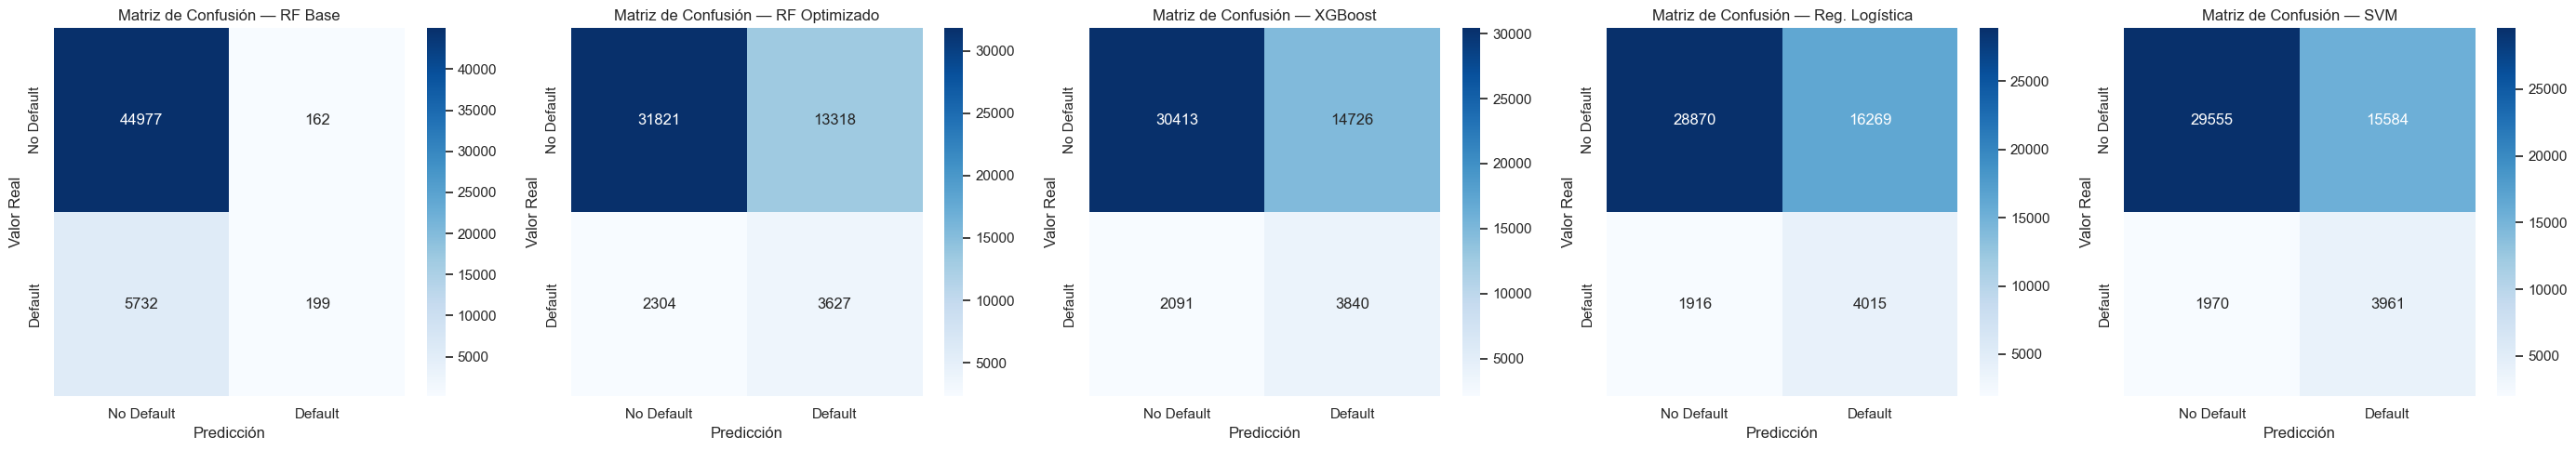

In [21]:
# Matrices de confusión para los 5 modelos
fig, axes = plt.subplots(1, 5, figsize=(28, 5))

matrices = [
    ('RF Base',       confusion_matrix(y_test, y_pred_rf_base)),
    ('RF Optimizado', confusion_matrix(y_test, y_pred_rf)),
    ('XGBoost',       confusion_matrix(y_test, y_pred_xgb)),
    ('Reg. Logística',confusion_matrix(y_test, y_pred_lr)),
    ('SVM',           confusion_matrix(y_test, y_pred_svm)),
]

for ax, (titulo, matriz) in zip(axes, matrices):
    sns.heatmap(
        matriz,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['No Default', 'Default'],
        yticklabels=['No Default', 'Default']
    )
    ax.set_title(f'Matriz de Confusión — {titulo}')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

### 11. Curva ROC y AUC

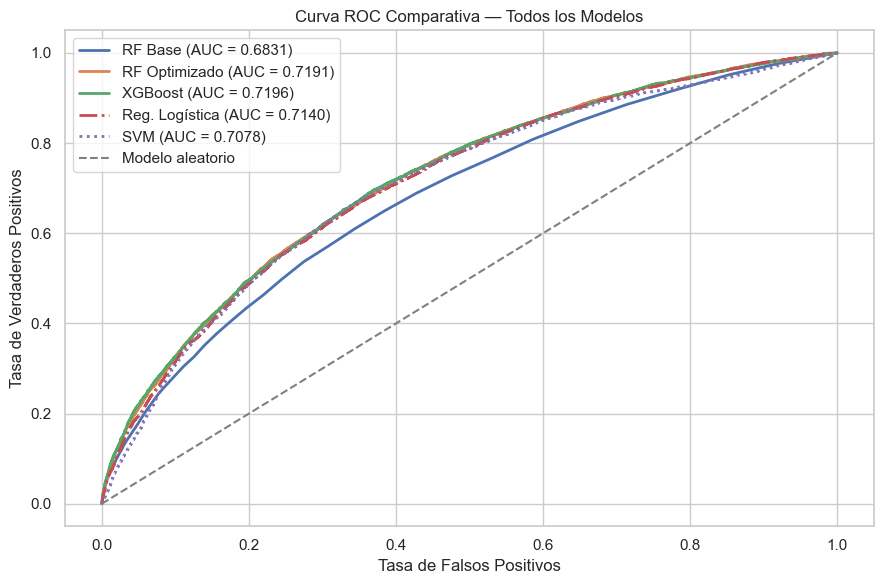

In [22]:
# Curva ROC para todos los modelos
auc_rf_base = roc_auc_score(y_test, y_prob_rf_base)
auc_rf      = roc_auc_score(y_test, y_prob_rf)
auc_xgb     = roc_auc_score(y_test, y_prob_xgb)
auc_lr      = roc_auc_score(y_test, y_prob_lr)
auc_svm     = roc_auc_score(y_test, y_prob_svm)

fpr_rf_base, tpr_rf_base, _ = roc_curve(y_test, y_prob_rf_base)
fpr_rf, tpr_rf, _             = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _          = roc_curve(y_test, y_prob_xgb)
fpr_lr, tpr_lr, _             = roc_curve(y_test, y_prob_lr)
fpr_svm, tpr_svm, _           = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(9, 6))
plt.plot(fpr_rf_base, tpr_rf_base, lw=2, label=f'RF Base (AUC = {auc_rf_base:.4f})')
plt.plot(fpr_rf, tpr_rf, lw=2, label=f'RF Optimizado (AUC = {auc_rf:.4f})')
plt.plot(fpr_xgb, tpr_xgb, lw=2, label=f'XGBoost (AUC = {auc_xgb:.4f})')
plt.plot(fpr_lr, tpr_lr, lw=2, linestyle='-.', label=f'Reg. Logística (AUC = {auc_lr:.4f})')
plt.plot(fpr_svm, tpr_svm, lw=2, linestyle=':', label=f'SVM (AUC = {auc_svm:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Modelo aleatorio')

plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC Comparativa — Todos los Modelos')
plt.legend()
plt.tight_layout()
plt.show()

### 12. Importancia de Variables

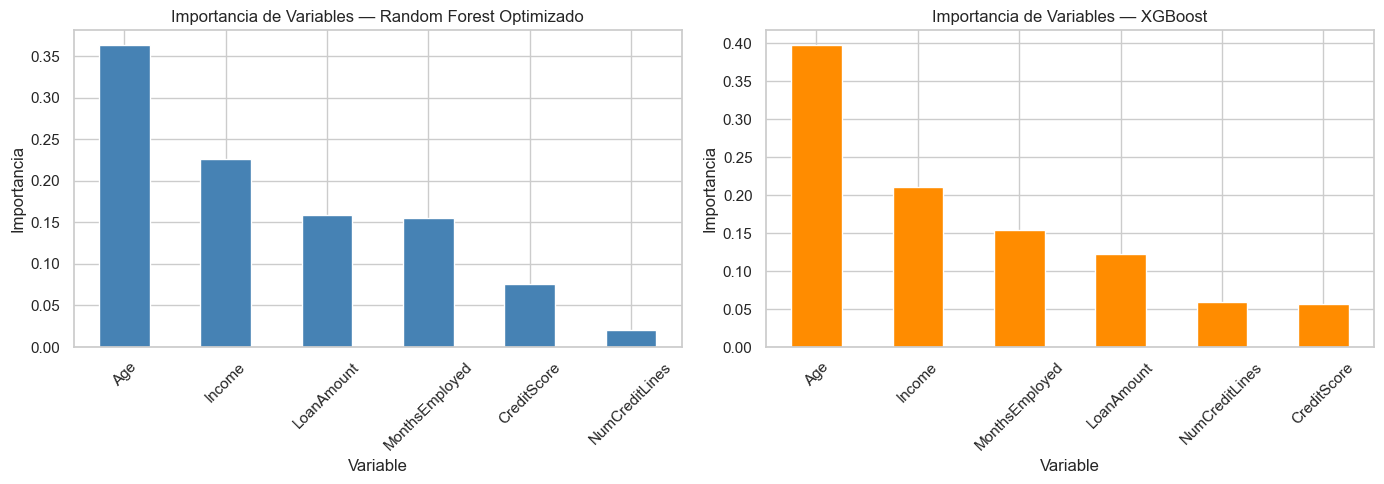

In [23]:
# Importancia de variables para Random Forest y XGBoost (6 features seleccionadas)
importancias_rf  = pd.Series(best_rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
importancias_xgb = pd.Series(best_xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

importancias_rf.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Importancia de Variables — Random Forest Optimizado')
axes[0].set_xlabel('Variable')
axes[0].set_ylabel('Importancia')
axes[0].tick_params(axis='x', rotation=45)

importancias_xgb.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Importancia de Variables — XGBoost')
axes[1].set_xlabel('Variable')
axes[1].set_ylabel('Importancia')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [24]:
print('Importancia de variables — Random Forest Optimizado')
print(np.round(importancias_rf, 4))

print('\nImportancia de variables — XGBoost')
print(np.round(importancias_xgb, 4))

Importancia de variables — Random Forest Optimizado
Age               0.3631
Income            0.2263
LoanAmount        0.1593
MonthsEmployed    0.1551
CreditScore       0.0760
NumCreditLines    0.0203
dtype: float64

Importancia de variables — XGBoost
Age               0.3972
Income            0.2105
MonthsEmployed    0.1540
LoanAmount        0.1224
NumCreditLines    0.0593
CreditScore       0.0566
dtype: float32


### 13. Simulación — ¿Le damos crédito a este cliente?

In [25]:
# Simulación con el primer cliente del conjunto de prueba
cliente_ejemplo        = X_test.iloc[[0]]
cliente_ejemplo_scaled = scaler.transform(cliente_ejemplo)

prob_rf_base = rf_base.predict_proba(cliente_ejemplo)[0][1]
prob_rf      = best_rf.predict_proba(cliente_ejemplo)[0][1]
prob_xgb     = best_xgb.predict_proba(cliente_ejemplo)[0][1]
prob_lr      = best_lr.predict_proba(cliente_ejemplo_scaled)[0][1]
prob_svm     = best_svm.predict_proba(cliente_ejemplo_scaled)[0][1]

print('=== Evaluación del Cliente ===')
print(f'Probabilidad de Default - RF Base:        {prob_rf_base * 100:.2f}%')
print(f'Probabilidad de Default - RF Optimizado:  {prob_rf * 100:.2f}%')
print(f'Probabilidad de Default - XGBoost:        {prob_xgb * 100:.2f}%')
print(f'Probabilidad de Default - Reg. Logística: {prob_lr * 100:.2f}%')
print(f'Probabilidad de Default - SVM:            {prob_svm * 100:.2f}%')

=== Evaluación del Cliente ===
Probabilidad de Default - RF Base:        10.00%
Probabilidad de Default - RF Optimizado:  35.92%
Probabilidad de Default - XGBoost:        39.77%
Probabilidad de Default - Reg. Logística: 32.40%
Probabilidad de Default - SVM:            8.72%


Decision con XGboost

In [26]:
probabilidad = prob_xgb

print('\n=== Decisión final basada en XGBoost ===')

if probabilidad < 0.30:
    print('Decisión: APROBADO ✓ — Riesgo bajo')
elif probabilidad < 0.60:
    print('Decisión: REVISAR ⚠ — Riesgo medio, considerar monto menor')
else:
    print('Decisión: RECHAZADO ✗ — Riesgo alto de default')


=== Decisión final basada en XGBoost ===
Decisión: REVISAR ⚠ — Riesgo medio, considerar monto menor


### 14. Resumen Final

In [27]:
print('======================================================')
print('              RESUMEN GENERAL DEL PROYECTO            ')
print('======================================================')
print(resultados.to_string(index=False))
print('======================================================')
print('Registros de entrenamiento:', X_train.shape[0])
print('Registros de prueba:       ', X_test.shape[0])
print('Variables utilizadas:      ', len(FEATURES))
print('Features:', FEATURES)
print('======================================================')
print('Escalado reutilizado para LR y SVM: Sí')
print('Búsqueda optimizada con RandomizedSearchCV: Sí')
print('SVM entrenado sobre submuestra estratificada: Sí')
print('======================================================')

              RESUMEN GENERAL DEL PROYECTO            
                  Modelo  Accuracy  Precision   Recall  F1-score      AUC
      Random Forest Base  0.884590   0.551247 0.033553  0.063255 0.683051
Random Forest Optimizado  0.694106   0.214045 0.611533  0.317101 0.719131
      XGBoost Optimizado  0.670707   0.206830 0.647446  0.313508 0.719560
     Regresión Logística  0.643920   0.197939 0.676952  0.306313 0.714013
                     SVM  0.656276   0.202661 0.667847  0.310959 0.707767
Registros de entrenamiento: 204277
Registros de prueba:        51070
Variables utilizadas:       6
Features: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines']
Escalado reutilizado para LR y SVM: Sí
Búsqueda optimizada con RandomizedSearchCV: Sí
SVM entrenado sobre submuestra estratificada: Sí


### 15. Conclusiones Académicas

In [28]:
# Identificar el mejor modelo por AUC
mejor_modelo = resultados.loc[resultados['AUC'].idxmax(), 'Modelo']
mejor_auc    = resultados['AUC'].max()
mejor_acc    = resultados.loc[resultados['AUC'].idxmax(), 'Accuracy']

print('======================================================')
print('            CONCLUSIONES DEL PROYECTO                 ')
print('======================================================')
print(f"\n1. Mejor modelo: {mejor_modelo}")
print(f"   - AUC:      {mejor_auc:.4f}")
print(f"   - Accuracy: {mejor_acc:.4f}")

print("""
2. Impacto de la reducción de variables:
   - Se redujeron 24 características a 6 variables clave.
   - Las 6 features seleccionadas (Age, Income, LoanAmount, CreditScore,
     MonthsEmployed, NumCreditLines) representan el perfil financiero
     y crediticio del solicitante.
   - Esta reducción simplifica el modelo, disminuye ruido y mejora la interpretabilidad.

3. Eficiencia computacional del flujo:
   - El escalado de variables se realizó una sola vez y se reutilizó para
     Regresión Logística y SVM.
   - RandomizedSearchCV redujo el número de combinaciones evaluadas,
     disminuyendo el tiempo total de entrenamiento.
   - SVM se entrenó sobre una submuestra estratificada del conjunto de entrenamiento,
     manteniendo proporciones de clase y haciendo viable su ejecución.
   - La búsqueda de hiperparámetros en SVM se realizó sin probability=True,
     y solo el modelo final se reentrenó con probabilidades para ROC/AUC.

4. Interpretación de resultados:
   - Random Forest y XGBoost capturan relaciones no lineales y suelen ofrecer
     alto desempeño en problemas de scoring crediticio.
   - La Regresión Logística aporta un baseline interpretable y eficiente.
   - SVM con kernel RBF puede ser competitivo, pero tiene mayor costo computacional,
     por lo que su uso requiere optimización del flujo de entrenamiento.

5. Justificación metodológica:
   - La selección de características reduce dimensionalidad y ruido.
   - La validación cruzada permite evaluar generalización sin fuga de datos.
   - La comparación entre modelos lineales y no lineales permite analizar
     diferentes enfoques de clasificación para el riesgo de crédito.
""")
print('======================================================')

            CONCLUSIONES DEL PROYECTO                 

1. Mejor modelo: XGBoost Optimizado
   - AUC:      0.7196
   - Accuracy: 0.6707

2. Impacto de la reducción de variables:
   - Se redujeron 24 características a 6 variables clave.
   - Las 6 features seleccionadas (Age, Income, LoanAmount, CreditScore,
     MonthsEmployed, NumCreditLines) representan el perfil financiero
     y crediticio del solicitante.
   - Esta reducción simplifica el modelo, disminuye ruido y mejora la interpretabilidad.

3. Eficiencia computacional del flujo:
   - El escalado de variables se realizó una sola vez y se reutilizó para
     Regresión Logística y SVM.
   - RandomizedSearchCV redujo el número de combinaciones evaluadas,
     disminuyendo el tiempo total de entrenamiento.
   - SVM se entrenó sobre una submuestra estratificada del conjunto de entrenamiento,
     manteniendo proporciones de clase y haciendo viable su ejecución.
   - La búsqueda de hiperparámetros en SVM se realizó sin probability=Tru